In [3]:
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.utils import to_categorical
import numpy as np
from sklearn.metrics import confusion_matrix
from keras.datasets import mnist


Text(0.5, 1.0, '0')

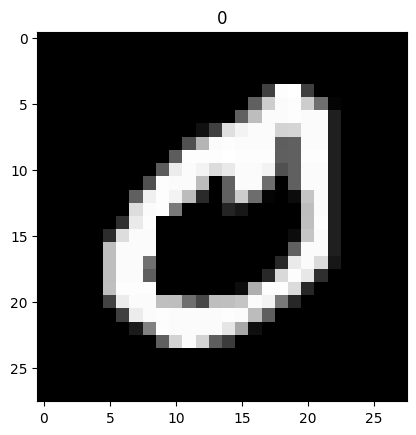

In [4]:
# Obtenção dos dados e divisão automática em treino e teste.
(X_treino, Y_treino),(X_teste, Y_teste) = mnist.load_data()

# Visualização de imagens específicas.
plt.imshow(X_treino[21], cmap = 'gray')
plt.title(Y_treino[21])

In [5]:
# Mudança de dimensão que esta em 28x28 e precisamos de 784.

X_treino = X_treino.reshape((len(X_treino), np.prod(X_treino.shape[1:])))
X_teste = X_teste.reshape((len(X_teste), np.prod(X_teste.shape[1:])))
X_teste[0]


array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [ ]:
#Transformação dos dados para float para podermos normalizar os dados

X_treino = X_treino.astype('float')
X_teste = X_teste.astype('float')

In [7]:
#Normalização (255 é o valor máximo de um pixel)

X_treino /= 255
X_teste /= 255

In [8]:
#Transformação para o formato dummy (temos 10 classes)

Y_treino = to_categorical(Y_treino, 10)
Y_teste = to_categorical(Y_teste, 10)
Y_teste[8]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [9]:
#Estrutura da rede neural: 784-64-64-64-10
#Dropout é utilizado para zerar uma porcentagem dos neurônios, para evitar o overfitting

modelo = Sequential()
modelo.add(Input(shape = (784,)))

# Primeira camada oculta.
modelo.add(Dense(units = 64,activation='relu'))
modelo.add(Dropout(0.2))

# Segunda camada oculta.
modelo.add(Dense(units = 64, activation= 'relu'))
modelo.add(Dropout(0.2))

# Terceira camada oculta
modelo.add(Dense(units = 64, activation='relu'))
modelo.add(Dropout(0.2))

# Camada de saída com softmax
modelo.add(Dense(units =10, activation='softmax'))

In [10]:
# Visualziação do modelo.

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,210 (231.29 KB)

 Trainable params: 59,210 (231.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Configuração de paraâmetros de rede neural e treinamento (utilizando a base de dados de validação).
# Na variável histórico temos os históricos (erro e accuracy).

modelo.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics= ['accuracy'])
historico = modelo.fit(X_treino, Y_treino, epochs = 20, validation_data=(X_teste, Y_teste))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8649 - loss: 0.4452 - val_accuracy: 0.9487 - val_loss: 0.1677
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9343 - loss: 0.2280 - val_accuracy: 0.9625 - val_loss: 0.1264
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9452 - loss: 0.1869 - val_accuracy: 0.9647 - val_loss: 0.1158
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9525 - loss: 0.1636 - val_accuracy: 0.9671 - val_loss: 0.1079
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9549 - loss: 0.1536 - val_accuracy: 0.9685 - val_loss: 0.1025
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9596 - loss: 0.1368 - val_accuracy: 0.9684 - val_loss: 0.1030
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9610 - loss: 0.1304 - val_accuracy: 0.9725 - val_loss: 0.0961
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9629 - loss: 0.1259 - 

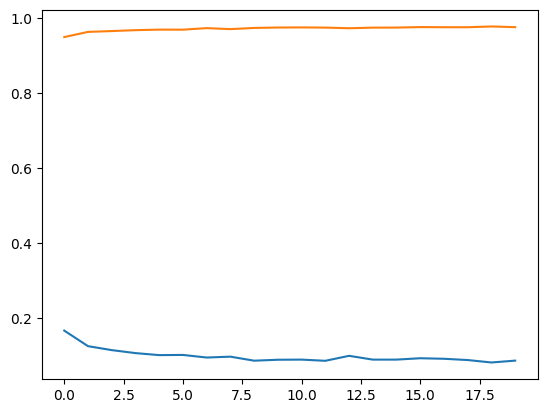

In [13]:
# Gráfico para visualizar os erros e accuracy.
historico.history.keys()

# Evolução do erro, azul.
plt.plot(historico.history['val_loss'])

# Taxa de acerto.
plt.plot(historico.history['val_accuracy'])

In [14]:
# Obtendo as previsões.

previsoes = modelo.predict(X_teste)
previsoes

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step


array([[5.4890248e-10, 6.3423488e-07, 9.4694178e-06, ..., 9.9993968e-01,
        4.5883830e-08, 6.3882067e-06],
       [3.4414002e-10, 1.3575927e-06, 9.9998629e-01, ..., 5.0792374e-07,
        1.2551345e-08, 5.6637209e-11],
       [1.2858797e-10, 9.9997771e-01, 1.7019553e-06, ..., 2.1032704e-06,
        1.7870996e-05, 1.6395335e-08],
       ...,
       [3.7506831e-11, 1.6055051e-11, 5.4154095e-09, ..., 1.5058923e-08,
        1.1682004e-11, 1.7194353e-06],
       [6.1713303e-14, 3.8686250e-12, 2.3271627e-16, ..., 7.9832489e-14,
        5.3854880e-08, 7.2408421e-09],
       [1.2958086e-10, 1.1509421e-12, 3.2489011e-10, ..., 7.4021964e-17,
        8.1524983e-14, 6.1522993e-15]], shape=(10000, 10), dtype=float32)

In [15]:
# Valor máximo (com a probabilidade maior por serem 10 saídas) e geração da matriz de confusão.

YT_matriz = [np.argmax(t) for t in Y_teste]
YP_matriz = [np.argmax(i) for i in previsoes]
confusao = confusion_matrix(YT_matriz, YP_matriz)
confusao

array([[ 973,    1,    1,    0,    0,    1,    1,    1,    2,    0],
       [   0, 1124,    3,    1,    0,    1,    2,    0,    4,    0],
       [   3,    0, 1011,    2,    4,    1,    1,    8,    2,    0],
       [   0,    0,    1,  991,    0,    4,    0,    8,    4,    2],
       [   2,    0,    4,    0,  962,    0,    4,    0,    2,    8],
       [   2,    2,    0,   11,    1,  862,    6,    3,    2,    3],
       [   9,    3,    1,    1,    4,    3,  935,    0,    2,    0],
       [   2,    7,    9,    1,    0,    1,    0, 1003,    1,    4],
       [  10,    5,    6,    4,    4,    8,    2,    9,  922,    4],
       [   3,    4,    1,    7,   11,    3,    0,   10,    2,  968]])

In [16]:
# Previsão com um novo registro, convertendo o array em matriz.

Y_treino[20]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [17]:
# Passo a mesma posição pro modelo prever.
novo = X_treino[20]

# De matriz para vetor.
novo = np.expand_dims(novo, axis = 0)

# Previsão.
pred = modelo.predict(novo)

# Maior valor.
pred = [np.argmax(t) for t in pred]
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


[np.int64(4)]